In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans as TextKMeans

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# 2. LOAD GlaucomaM.csv
# ============================================================

file_path = "GlaucomaM.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (196, 63)

First 5 rows:


,ag,at,as,an,ai,eag,eat,eas,ean,eai,...,tmt,tms,tmn,tmi,mr,rnf,mdic,emd,mv,Class
0,2.220,0.354,0.580,0.686,0.601,1.267,0.336,0.346,0.255,0.331,...,-0.018,-0.230,-0.510,-0.158,0.841,0.410,0.137,0.239,0.035,normal
1,2.681,0.475,0.672,0.868,0.667,2.053,0.440,0.520,0.639,0.454,...,-0.014,-0.165,-0.317,-0.192,0.924,0.256,0.252,0.329,0.022,normal
2,1.979,0.343,0.508,0.624,0.504,1.200,0.299,0.396,0.259,0.246,...,-0.097,-0.235,-0.337,-0.020,0.795,0.378,0.152,0.250,0.029,normal
3,1.747,0.269,0.476,0.525,0.476,0.612,0.147,0.017,0.044,0.405,...,-0.035,-0.449,-0.217,-0.091,0.746,0.200,0.027,0.078,0.023,normal
4,2.990,0.599,0.686,1.039,0.667,2.513,0.543,0.607,0.871,0.492,...,-0.105,0.084,-0.012,-0.054,0.977,0.193,0.297,0.354,0.034,normal



Column names:
['ag', 'at', 'as', 'an', 'ai', 'eag', 'eat', 'eas', 'ean', 'eai', 'abrg', 'abrt', 'abrs', 'abrn', 'abri', 'hic', 'mhcg', 'mhct', 'mhcs', 'mhcn', 'mhci', 'phcg', 'phct', 'phcs', 'phcn', 'phci', 'hvc', 'vbsg', 'vbst', 'vbss', 'vbsn', 'vbsi', 'vasg', 'vast', 'vass', 'vasn', 'vasi', 'vbrg', 'vbrt', 'vbrs', 'vbrn', 'vbri', 'varg', 'vart', 'vars', 'varn', 'vari', 'mdg', 'mdt', 'mds', 'mdn', 'mdi', 'tmg', 'tmt', 'tms', 'tmn', 'tmi', 'mr', 'rnf', 'mdic', 'emd', 'mv', 'Class']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 63 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ag      196 non-null    float64
 1   at      196 non-null    float64
 2   as      196 non-null    float64
 3   an      196 non-null    float64
 4   ai      196 non-null    float64
 5   eag     196 non-null    float64
 6   eat     196 non-null    float64
 7   eas     196 non-null    float64
 8   ean     196 non-null 

In [3]:
# ============================================================
# 3. BASIC DATA EXPLORATION
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe(include="all").T)

Number of rows: 196
Number of columns: 63

Missing values:


ag       0
at       0
as       0
an       0
ai       0
        ..
rnf      0
mdic     0
emd      0
mv       0
Class    0
Length: 63, dtype: int64


Duplicate rows: 0

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ag,196.0,NaN,NaN,NaN,2.606531,0.659789,1.312,2.13925,2.533,2.9435,5.444
at,196.0,NaN,NaN,NaN,0.45898,0.127013,0.201,0.37075,0.4445,0.528,0.967
as,196.0,NaN,NaN,NaN,0.651781,0.158462,0.345,0.5385,0.6305,0.73825,1.34
an,196.0,NaN,NaN,NaN,0.835929,0.222166,0.397,0.681,0.8085,0.952,1.765
ai,196.0,NaN,NaN,NaN,0.659995,0.161065,0.369,0.5505,0.632,0.74975,1.373
...,...,...,...,...,...,...,...,...,...,...,...
rnf,196.0,NaN,NaN,NaN,0.182383,0.09408,-0.297,0.11975,0.182,0.237,0.451
mdic,196.0,NaN,NaN,NaN,0.23127,0.123882,0.012,0.144,0.227,0.29925,0.663
emd,196.0,NaN,NaN,NaN,0.308903,0.128246,0.047,0.2305,0.298,0.37925,0.743
mv,196.0,NaN,NaN,NaN,0.033541,0.02185,0.0,0.021,0.028,0.03825,0.183


In [4]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (196, 63)


In [5]:
# ============================================================
# 5. IDENTIFY NUMERIC, CATEGORICAL AND TEXT COLUMNS
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical/Text columns:")
print(categorical_cols)

Numeric columns:
['ag', 'at', 'as', 'an', 'ai', 'eag', 'eat', 'eas', 'ean', 'eai', 'abrg', 'abrt', 'abrs', 'abrn', 'abri', 'hic', 'mhcg', 'mhct', 'mhcs', 'mhcn', 'mhci', 'phcg', 'phct', 'phcs', 'phcn', 'phci', 'hvc', 'vbsg', 'vbst', 'vbss', 'vbsn', 'vbsi', 'vasg', 'vast', 'vass', 'vasn', 'vasi', 'vbrg', 'vbrt', 'vbrs', 'vbrn', 'vbri', 'varg', 'vart', 'vars', 'varn', 'vari', 'mdg', 'mdt', 'mds', 'mdn', 'mdi', 'tmg', 'tmt', 'tms', 'tmn', 'tmi', 'mr', 'rnf', 'mdic', 'emd', 'mv']

Categorical/Text columns:
['Class']


In [6]:
# ============================================================
# 6. PREPARE NUMERIC DATA FOR K-MEANS
# ============================================================

if len(numeric_cols) == 0:
    raise ValueError("No numeric columns were found in the dataset.")

X_numeric = df[numeric_cols].copy()

# Replace infinite values
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)

# Fill missing numeric values with the median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_numeric)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Preprocessed numeric data shape:", X_scaled.shape)

Preprocessed numeric data shape: (196, 62)


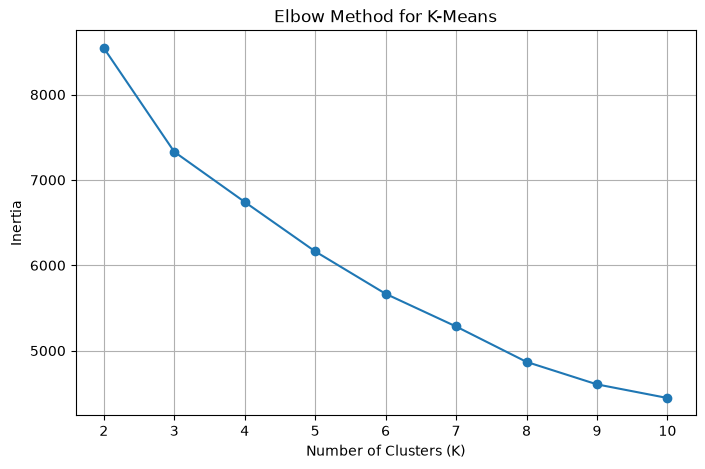

In [7]:
# ============================================================
# 7. ELBOW METHOD
# ============================================================

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

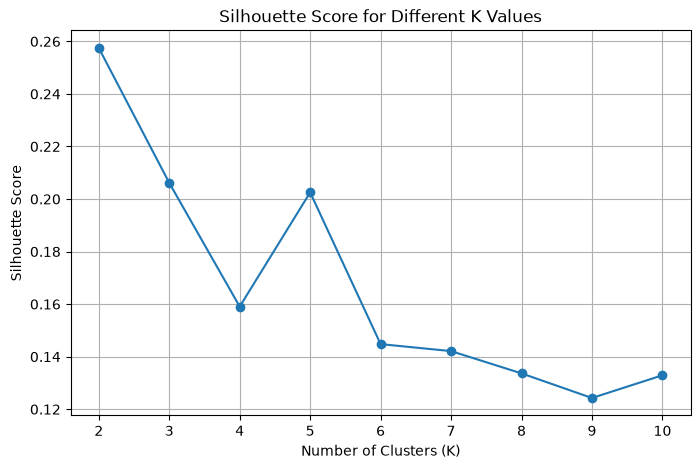

Best K according to silhouette score: 2
Best silhouette score: 0.25749094009519713


In [8]:
# ============================================================
# 8. SILHOUETTE SCORE
# ============================================================

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid(True)
plt.show()

best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best K according to silhouette score:", best_k)
print("Best silhouette score:", max(silhouette_scores))

In [9]:
# ============================================================
# 9. APPLY K-MEANS
# ============================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = clusters

print("Cluster counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())

Cluster counts:
KMeans_Cluster
0     82
1    114
Name: count, dtype: int64


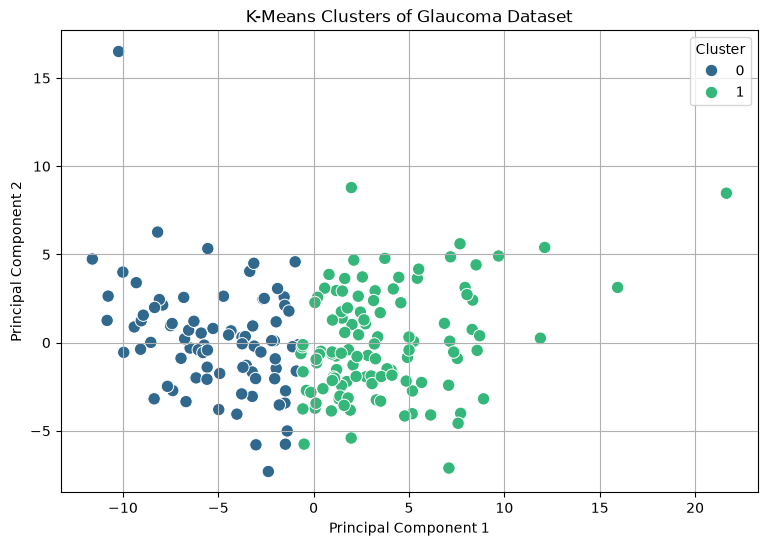

Variance explained by PC1 and PC2: [0.46829513 0.15039238]


In [10]:
# ============================================================
# 10. PCA VISUALIZATION
# ============================================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=80
)

plt.title("K-Means Clusters of Glaucoma Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

print(
    "Variance explained by PC1 and PC2:",
    pca.explained_variance_ratio_
)

In [11]:
# ============================================================
# 11. CLUSTER PROFILE
# ============================================================

cluster_profile = df.groupby("KMeans_Cluster")[numeric_cols].mean()

display(cluster_profile)

,ag,at,as,an,ai,eag,eat,eas,ean,eai,...,tmg,tmt,tms,tmn,tmi,mr,rnf,mdic,emd,mv
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.215585,0.38239,0.563061,0.702268,0.568000,1.251402,0.313390,0.350427,0.254939,0.332695,...,-0.180341,-0.082963,-0.157939,-0.228195,-0.134220,0.835890,0.237744,0.12539,0.209854,0.032805
1,2.887737,0.51407,0.715596,0.932070,0.726167,2.322070,0.473254,0.584211,0.678360,0.586123,...,-0.030149,0.051667,0.045167,-0.088947,0.033772,0.954684,0.142561,0.30743,0.380149,0.034070


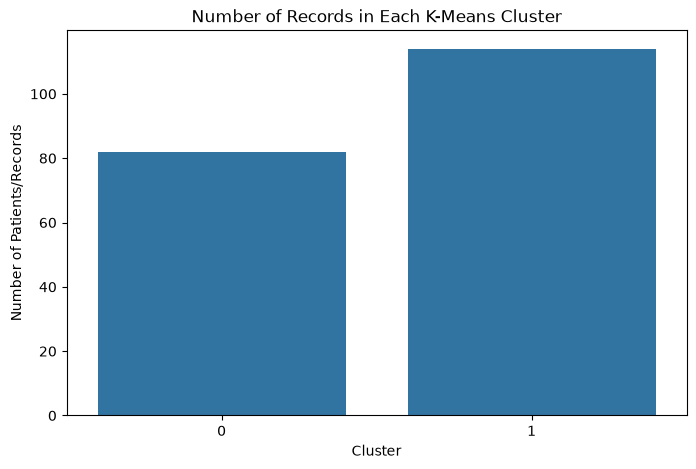

In [12]:
# ============================================================
# 12. CLUSTER SIZE
# ============================================================

cluster_size = df["KMeans_Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_size.index,
    y=cluster_size.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Patients/Records")
plt.title("Number of Records in Each K-Means Cluster")
plt.show()

In [13]:
# ============================================================
# 13. FIND POSSIBLE TEXT COLUMNS
# ============================================================

text_candidates = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Possible text columns:")
print(text_candidates)

Possible text columns:
['Class']


In [15]:
# ============================================================
# 20. SAVE RESULTS
# ============================================================

output_file = "GlaucomaM_KMeans_NLP_Results.csv"

df.to_csv(
    output_file,
    index=False
)

print(f"Results saved to: {output_file}")

Results saved to: GlaucomaM_KMeans_NLP_Results.csv
